In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# LOAD DATA

df = pd.read_csv("Rohith_A_P_Integrated_Uber_Traffic_Dataset.csv")

df['DateTime'] = pd.to_datetime(df['DateTime'])

In [20]:
# FEATURE SELECTION

features=[

'Junction',
'Hour',
'Month',
'Temperature',
'Rainfall',
'Humidity',
'WindSpeed',
'Is_Weekend',
'Peak_Hour',
'Is_Holiday',
'Special_Event',

'Lag_1',
'Lag_2',
'Lag_6',
'Lag_12',
'Lag_24',

'Rolling_Mean_3',
'Rolling_Mean_6',
'Rolling_STD_3'
]

target='Vehicles'

X=df[features]
y=df[target]


In [21]:
# TIME-BASED SPLIT

split_index=int(len(df)*0.8)

X_train=X.iloc[:split_index]
X_test=X.iloc[split_index:]

y_train=y.iloc[:split_index]
y_test=y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(38467, 19)
(9617, 19)


In [22]:
# HYPERPARAMETER TUNING

param_grid={

    'n_estimators':[100,200],

    'max_depth':[10,15,None],

    'min_samples_split':[2,5]

}

rf=RandomForestRegressor(
    random_state=42
)

grid=GridSearchCV(

    rf,
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1

)

grid.fit(X_train,y_train)

best_model=grid.best_estimator_

print(
    "Best Parameters:",
    grid.best_params_
)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
# MODEL TRAINING

best_model.fit(
    X_train,
    y_train
)

predictions=best_model.predict(
    X_test
)

In [24]:
# EVALUATION METRICS

mae=mean_absolute_error(
    y_test,
    predictions
)

rmse=np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2=r2_score(
    y_test,
    predictions
)

print("\nMAE:",mae)

print("\nRMSE:",rmse)

print("\nR²:",r2)


MAE: 0.3465197046896121

RMSE: 1.8955189958688619

R²: 0.9638530432338247


In [19]:
#Improve the dataset by adding lag features. Traffic forecasting depends heavily on previous traffic values.

df['Lag_6'] = df['Vehicles'].shift(6)

df['Lag_12'] = df['Vehicles'].shift(12)

df['Rolling_Mean_6'] = (
    df['Vehicles']
    .rolling(6)
    .mean()
)

df['Rolling_STD_3'] = (
    df['Vehicles']
    .rolling(3)
    .std()
)

df.dropna(inplace=True)

In [25]:
# TIME SERIES CROSS VALIDATION

tscv=TimeSeriesSplit(
    n_splits=5
)

scores=[]

for train_idx,test_idx in tscv.split(X):

    X_train_cv=X.iloc[train_idx]
    X_test_cv=X.iloc[test_idx]

    y_train_cv=y.iloc[train_idx]
    y_test_cv=y.iloc[test_idx]

    best_model.fit(
        X_train_cv,
        y_train_cv
    )

    preds=best_model.predict(
        X_test_cv
    )

    score=r2_score(
        y_test_cv,
        preds
    )

    scores.append(score)

print(
    "\nCross Validation R² Scores:"
)

print(scores)

print(
    "\nAverage R²:",
    np.mean(scores)
)



Cross Validation R² Scores:
[0.9337319758178984, 0.9501744799428412, 0.987525202198898, 0.9256426924696357, 0.9744556128601584]

Average R²: 0.9543059926578863


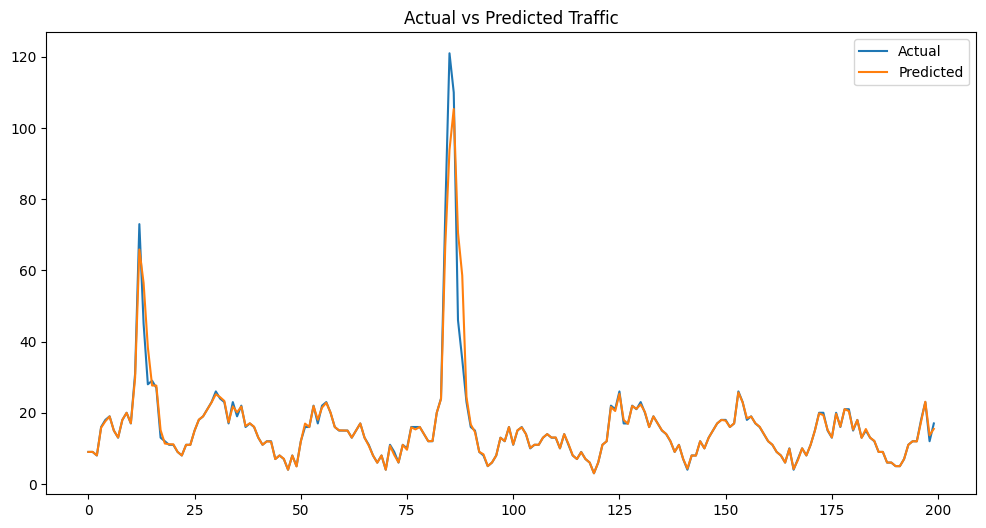

In [26]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    predictions[:200],
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Traffic"
)

plt.show()


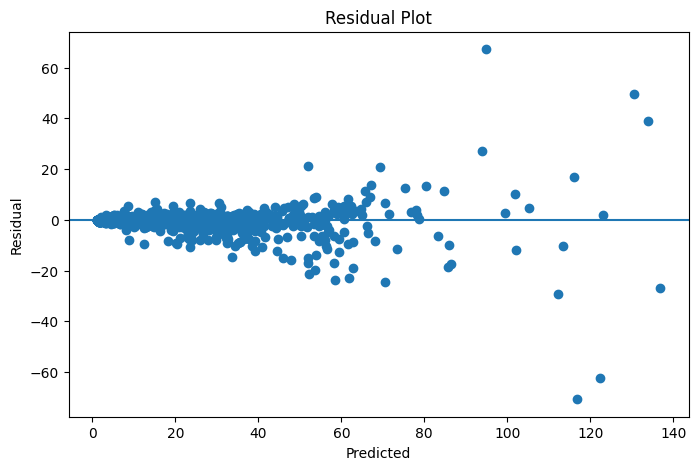

In [27]:
# RESIDUAL PLOT

residuals=y_test-predictions

plt.figure(figsize=(8,5))

plt.scatter(
    predictions,
    residuals
)

plt.axhline(
    y=0
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot"
)

plt.show()

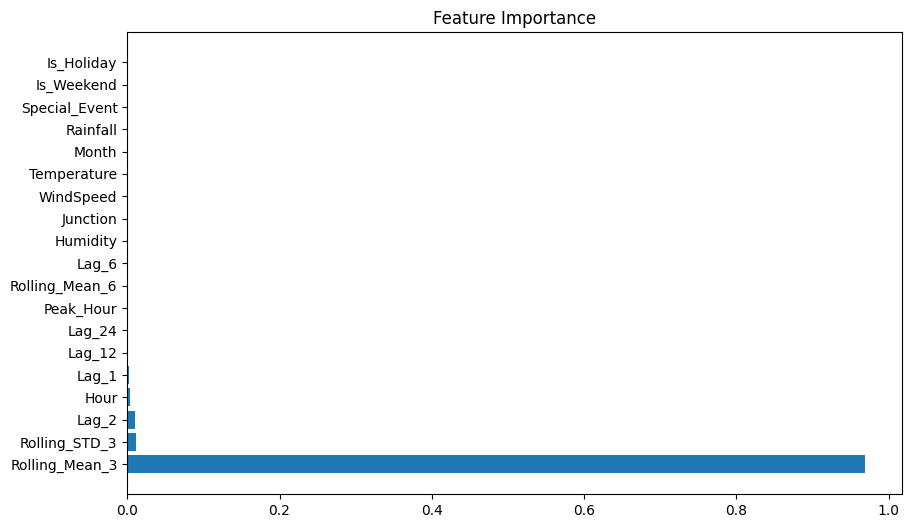

In [28]:
# FEATURE IMPORTANCE

importance=pd.DataFrame({

    'Feature':features,

    'Importance':
    best_model.feature_importances_

})

importance=importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(

    importance['Feature'],
    importance['Importance']

)

plt.title(
    "Feature Importance"
)

plt.show()